In [9]:
import xml.etree.ElementTree as ET
import pandas as pd
from pandas.api.types import is_numeric_dtype
from xml.dom import minidom
import uuid
import io
import pandas as pd

# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv("dataset_categorical.csv", sep=';')


TARGET = "Loan_Approval"

df = df.astype(str)

# ============================================================
# CANONICAL PRISM
# ============================================================

class CanonicalPrism:

    def __init__(self):
        self.rules = {}
        self.target_col = None
        self.default_target = None # Initialize default_target

    def _best_term(self, df, target, cls, used):
        best, best_prob = None, -1

        for col in df.columns:
            if col == target or col in used:
                continue

            for val in df[col].unique():
                sub = df[df[col] == val]
                if sub.empty:
                    continue

                prob = (sub[target] == cls).mean()
                if prob > best_prob:
                    best_prob = prob
                    best = (col, val)

        return best

    def _learn_class(self, df, target, cls):
        remaining = df.copy()
        rules = []

        while (remaining[target] == cls).any():
            rule, used = [], []
            work = remaining.copy()

            while True:
                term = self._best_term(work, target, cls, used)
                if term is None:
                    break

                col, val = term
                rule.append((col, val))
                used.append(col)
                work = work[work[col] == val]

                if (work[target] == cls).all():
                    break

            rules.append(rule)
            remaining = remaining.drop(work.index)

        return rules

    def fit(self, df, target):
        self.target_col = target
        for cls in df[target].unique():
            self.rules[cls] = self._learn_class(df, target, cls)

        # Determine default target (e.g., majority class)
        if not df.empty:
            self.default_target = df[target].mode()[0]
        else:
            self.default_target = "UNKNOWN" # Fallback

        return self.rules

# ============================================================
# TRAIN PRISM
# ============================================================

prism = CanonicalPrism()
prism.fit(df, TARGET)

# ============================================================
# PRINT FINAL RULES
# ============================================================

print("\n FINAL PRISM RULES (SYMBOLIC DATASET):\n")

for cls, rules in prism.rules.items():
    print(f"=== CLASS {cls} ===")
    for i, rule in enumerate(rules, 1):
        conditions = [f"{attr} = {val}" for attr, val in rule]
        print(f"Rule {i}: IF {' AND '.join(conditions)} THEN {cls}")
    print()


# ============================================================
# EXPORT PRISM → DMN (Camunda)
# ============================================================

def export_prism_to_dmn(prism, decision_name, filename, feature_columns):

    inputs = [c for c in feature_columns if c != prism.target_col]

    definitions = ET.Element(
        "definitions",
        {
            "xmlns": "https://www.omg.org/spec/DMN/20191111/MODEL/",
            "xmlns:camunda": "http://camunda.org/schema/1.0/dmn",
            "id": f"def_{uuid.uuid4()}",
            "name": decision_name,
            "namespace": "http://camunda.org/schema/1.0/dmn"
        }
    )

    decision = ET.SubElement(
        definitions, "decision",
        {"id": f"dec_{uuid.uuid4()}", "name": decision_name}
    )

    table = ET.SubElement(
        decision, "decisionTable",
        {"id": f"dt_{uuid.uuid4()}", "hitPolicy": "FIRST"}
    )

    # Inputs
    for inp in inputs:
        i = ET.SubElement(table, "input")
        expr = ET.SubElement(i, "inputExpression", {"typeRef": "string"})
        ET.SubElement(expr, "text").text = inp

    # Output
    ET.SubElement(
        table, "output",
        {"name": prism.target_col, "typeRef": "string"}
    )

    # Rules
    for cls, rules in prism.rules.items():
        for rule in rules:
            r = ET.SubElement(table, "rule")
            rule_map = dict(rule)

            for inp in inputs:
                e = ET.SubElement(r, "inputEntry")
                ET.SubElement(e, "text").text = (
                    f'"{rule_map[inp]}"' if inp in rule_map else "-"
                )

            out = ET.SubElement(r, "outputEntry")
            ET.SubElement(out, "text").text = cls

    # Default rule (last)
    default_rule = ET.SubElement(table, "rule")
    for _ in inputs:
        e = ET.SubElement(default_rule, "inputEntry")
        ET.SubElement(e, "text").text = "-"
    out = ET.SubElement(default_rule, "outputEntry")
    ET.SubElement(out, "text").text = prism.default_target

    xml = minidom.parseString(
        ET.tostring(definitions, encoding="utf-8")
    ).toprettyxml(indent="  ")

    with open(filename, "w", encoding="utf-8") as f:
        f.write(xml)

    print(f" DMN αρχείο δημιουργήθηκε: {filename}")

# ============================================================
# CREATE DMN FILE
# ============================================================

export_prism_to_dmn(
    prism,
    decision_name="PRISM Loan Approval",
    filename="LoanPrism.dmn",
    feature_columns=df.columns.tolist()
)


 FINAL PRISM RULES (SYMBOLIC DATASET):

=== CLASS Reject ===
Rule 1: IF Age = old THEN Reject
Rule 2: IF Age = underage THEN Reject
Rule 3: IF Income = low THEN Reject

=== CLASS Approve ===
Rule 1: IF Age = middle AND Income = mid THEN Approve
Rule 2: IF Income = high AND Age = middle THEN Approve

 DMN αρχείο δημιουργήθηκε: LoanPrism.dmn


DMN generated: LoanTree.dmn


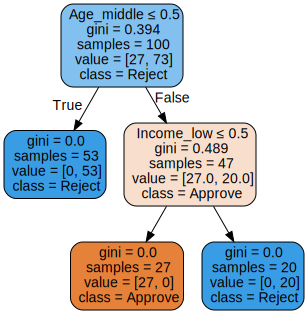

In [11]:
import numpy as np
import pandas as pd
import xml.etree.ElementTree as et
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import graphviz
import io
import pandas as pd

# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv("dataset_loan.csv", sep=';')

TARGET = "Loan_Approval"
y = df[TARGET]
X = df.drop(columns=[TARGET])

# Convert categorical features to numerical using one-hot encoding
X = pd.get_dummies(X, columns=['Age', 'Income'], drop_first=False)

# ============================================================
# TRAIN DECISION TREE
# ============================================================

clf = DecisionTreeClassifier(
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

clf.fit(X.values, y.values)

# ============================================================
# xmlDmn CLASS
# ============================================================

class xmlDmn:

    def __init__(self):
        self._id = 0

        self.root = et.Element(
            "definitions",
            {
                "xmlns": "http://www.omg.org/spec/DMN/20151101/dmn.xsd",
                "id": "definitions_1",
                "name": "Loan Decision Model",
                "namespace": "http://example.org/dmn",
            },
        )

        self.decision = et.SubElement(
            self.root, "decision", {"id": "decision_1", "name": "Loan Approval"}
        )

        self.table = et.SubElement(
            self.decision,
            "decisionTable",
            {"id": "decisionTable_1", "hitPolicy": "UNIQUE"},
        )

    def _gen(self, prefix):
        self._id += 1
        return f"{prefix}{self._id}"

    def create_columns(self, features, target):
        for f in features:
            inp = et.SubElement(self.table, "input", {"id": self._gen("in_")})
            expr = et.SubElement(
                inp,
                "inputExpression",
                {"id": self._gen("expr_"), "typeRef": "double"},
            )
            et.SubElement(expr, "text").text = f

        et.SubElement(
            self.table,
            "output",
            {"id": self._gen("out_"), "name": target, "typeRef": "string"},
        )

    def add_rule(self, conditions, output):
        r = et.SubElement(self.table, "rule", {"id": self._gen("rule_")})

        for c in conditions:
            cell = et.SubElement(r, "inputEntry", {"id": self._gen("cell_")})
            et.SubElement(cell, "text").text = c

        out = et.SubElement(r, "outputEntry", {"id": self._gen("outc_")})
        et.SubElement(out, "text").text = str(output)

    def save(self, filename):
        et.ElementTree(self.root).write(
            filename, encoding="utf-8", xml_declaration=True
        )
        return filename

# ============================================================
# DECISION TREE → DMN CONVERTER
# ============================================================

class clfDmn:

    def __init__(self, clf, X, y, target):
        self.clf = clf
        self.X = X
        self.y = y
        self.features = X.columns.tolist()
        self.target = target
        self.xml = xmlDmn()

    def generate(self):
        tree_ = self.clf.tree_
        left = tree_.children_left
        right = tree_.children_right
        threshold = tree_.threshold

        self.xml.create_columns(self.features, self.target)

        paths = self.clf.decision_path(self.X.values)
        leaves = np.where((left == -1) & (right == -1))[0]

        for leaf in leaves:
            rows = paths.getcol(leaf).nonzero()[0]
            if len(rows) == 0:
                continue

            sample = rows[0]
            nodes = paths.indices[
                paths.indptr[sample] : paths.indptr[sample + 1]
            ]

            rule = ["-" for _ in self.features]

            for i in range(len(nodes) - 1):
                n = nodes[i]
                f_id = tree_.feature[n]
                if f_id < 0:
                    continue

                thr = threshold[n]
                if nodes[i + 1] == left[n]:
                    rule[f_id] = f"<= {thr:.2f}"
                else:
                    rule[f_id] = f"> {thr:.2f}"

            cls_numeric = self.clf.classes_[np.argmax(tree_.value[leaf])]

            cls_label = cls_numeric

            self.xml.add_rule(rule, cls_label)


        return self.xml.save("LoanTree.dmn")

# ============================================================
# RUN DMN GENERATION
# ============================================================

converter = clfDmn(clf, X, y, TARGET)
print("DMN generated:", converter.generate())

# ============================================================
# VISUALIZE TREE
# ============================================================

dot = tree.export_graphviz(
    clf,
    feature_names=X.columns,
    class_names=clf.classes_,
    filled=True,
    rounded=True,
    label="all",
    special_characters=True
)

# ============================================================
# SAVE TREE AS IMAGE
# ============================================================

graph = graphviz.Source(dot)
graph.format = "png"
graph.render("loan_decision_tree", view=False)


graphviz.Source(dot)
